In [56]:
import pandas as pd
import numpy as np
import json

In [84]:
MODELS = [
    "models_saved/qwen/Qwen_Death-Raider_HiPO-Qwen2.5-Ra-only.json",
    "models_saved/qwen/Qwen_Death-Raider_HiPO-Qwen2.5-Mt-only.json",
    "models_saved/qwen/Qwen_Death-Raider_HiPO-Qwen2.5-Rq-only.json",
    "models_saved/qwen/Qwen_Death-Raider_HiPO-Qwen2.5-seq-0.json",
    "models_saved/qwen/Qwen_Death-Raider_HiPO-Qwen2.5-seq-1.json",
    "models_saved/qwen/Qwen_Death-Raider_HiPO-Qwen2.5-seq-2.json",
    "models_saved/qwen/Qwen_Death-Raider_DPO-Qwen.json",
    "models_saved/qwen/Qwen_Death-Raider_SFT-Qwen.json",
    "models_saved/qwen/Qwen_Qwen_Qwen2.5-7B-Instruct.json",
    'models_saved/llama/Llama_Death-Raider_HiPO-Llama3.1-Rq-only.json',
    'models_saved/llama/Llama_Death-Raider_HiPO-Llama3.1-Mt-only.json',
    'models_saved/llama/Llama_Death-Raider_HiPO-Llama3.1-Ra-only.json',
    'models_saved/llama/Llama_Death-Raider_HiPO-Llama3.1-Rq-bias-ind.json',
    'models_saved/llama/Llama_Death-Raider_HiPO-Llama3.1-Mt-bias-ind.json',
    'models_saved/llama/Llama_Death-Raider_HiPO-Llama3.1-eq-ind.json',
    'models_saved/llama/Llama_Death-Raider_HiPO-Llama3.1-seq-0.json',
    'models_saved/llama/Llama_Death-Raider_HiPO-Llama3.1-seq-1.json',
    'models_saved/llama/Llama_Death-Raider_HiPO-Llama3.1-seq-2.json',
    'models_saved/llama/Llama_meta-llama_Meta-Llama-3.1-8B-Instruct.json',
    'models_saved/llama/Llama_Death-Raider_DPO-Llama3.1.json',
]
ablatiobn_names = [

    'Ra-only',
    'Mt-only',
    'Rq-only',
    'seq-0',
    'seq-1',
    'seq-2',
    "DPO",
    'SFT',
    'Base',

    'Rq-only',
    'Mt-only',
    'Ra-only',
    'Rq-Bias',
    'Mt-Bias',
    'Equal-Bias',
    'seq-0',
    'seq-1',
    'seq-2',
    'Base',
    'DPO'


]

In [85]:
imp_columns = [
    "Logical Flow",
    "Structural Organization",
    "Consistency",
    # "Factual Correctness",
    "Domain Knowledge Application",
    "Reasoning Validity",
    # "Final Answer Correctness",
    "Strategy Usefulness",
    "Progress Toward Solution",
    "Partial Success Recognition",
    "Error Robustness",
    # "verbosity",
    # "final_comment"
]

In [86]:
final_df = pd.DataFrame()
all_df = pd.DataFrame()
accuracies_df = pd.DataFrame()
bench = {
    'gsm': 500,
    'math500': 500,
    'aime24': 30,
    'gk': 385,
    'Minerva': 272
} 

bench_names = np.concatenate([np.repeat(k, v) for k, v in bench.items()])


for model in MODELS:
    print(model)
    with open(model, "r") as f:
        data = f.read()
    data = pd.read_json(data)
    data['bench'] = bench_names[:len(data)]
    data['model'] = model.split('/')[1]
    data['model_type'] = ablatiobn_names[MODELS.index(model)]

    accuracies = data.groupby('bench')['Final Answer Correctness'].mean().to_frame().T
    accuracies_df = pd.concat([accuracies_df, accuracies])
    print(ablatiobn_names[MODELS.index(model)])
    # print(data[['Final Answer Correctness', 'Factual Correctness']].mean()*np.array([10,10]))
    # print(accuracies)
    print("")
    plotting_data = data[imp_columns].mean().to_frame().T
    final_df = pd.concat([final_df, plotting_data], ignore_index=True)
    all_df = pd.concat([all_df, data], ignore_index=True)


models_saved/qwen/Qwen_Death-Raider_HiPO-Qwen2.5-Ra-only.json
Ra-only

models_saved/qwen/Qwen_Death-Raider_HiPO-Qwen2.5-Mt-only.json
Mt-only

models_saved/qwen/Qwen_Death-Raider_HiPO-Qwen2.5-Rq-only.json
Rq-only

models_saved/qwen/Qwen_Death-Raider_HiPO-Qwen2.5-seq-0.json
seq-0

models_saved/qwen/Qwen_Death-Raider_HiPO-Qwen2.5-seq-1.json


C:\Users\kachr\AppData\Local\Temp\ipykernel_12780\766881167.py:19: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data = pd.read_json(data)
C:\Users\kachr\AppData\Local\Temp\ipykernel_12780\766881167.py:19: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data = pd.read_json(data)
C:\Users\kachr\AppData\Local\Temp\ipykernel_12780\766881167.py:19: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data = pd.read_json(data)
C:\Users\kachr\AppData\Local\Temp\ipykernel_12780\766881167.py:19: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap

seq-1

models_saved/qwen/Qwen_Death-Raider_HiPO-Qwen2.5-seq-2.json
seq-2

models_saved/qwen/Qwen_Death-Raider_DPO-Qwen.json
DPO

models_saved/qwen/Qwen_Death-Raider_SFT-Qwen.json
SFT

models_saved/qwen/Qwen_Qwen_Qwen2.5-7B-Instruct.json


C:\Users\kachr\AppData\Local\Temp\ipykernel_12780\766881167.py:19: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data = pd.read_json(data)
C:\Users\kachr\AppData\Local\Temp\ipykernel_12780\766881167.py:19: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data = pd.read_json(data)
C:\Users\kachr\AppData\Local\Temp\ipykernel_12780\766881167.py:19: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data = pd.read_json(data)
C:\Users\kachr\AppData\Local\Temp\ipykernel_12780\766881167.py:19: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap

Base

models_saved/llama/Llama_Death-Raider_HiPO-Llama3.1-Rq-only.json
Rq-only

models_saved/llama/Llama_Death-Raider_HiPO-Llama3.1-Mt-only.json
Mt-only

models_saved/llama/Llama_Death-Raider_HiPO-Llama3.1-Ra-only.json


C:\Users\kachr\AppData\Local\Temp\ipykernel_12780\766881167.py:19: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data = pd.read_json(data)
C:\Users\kachr\AppData\Local\Temp\ipykernel_12780\766881167.py:19: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data = pd.read_json(data)
C:\Users\kachr\AppData\Local\Temp\ipykernel_12780\766881167.py:19: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data = pd.read_json(data)
C:\Users\kachr\AppData\Local\Temp\ipykernel_12780\766881167.py:19: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap

Ra-only

models_saved/llama/Llama_Death-Raider_HiPO-Llama3.1-Rq-bias-ind.json
Rq-Bias

models_saved/llama/Llama_Death-Raider_HiPO-Llama3.1-Mt-bias-ind.json
Mt-Bias

models_saved/llama/Llama_Death-Raider_HiPO-Llama3.1-eq-ind.json


C:\Users\kachr\AppData\Local\Temp\ipykernel_12780\766881167.py:19: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data = pd.read_json(data)
C:\Users\kachr\AppData\Local\Temp\ipykernel_12780\766881167.py:19: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data = pd.read_json(data)
C:\Users\kachr\AppData\Local\Temp\ipykernel_12780\766881167.py:19: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data = pd.read_json(data)
C:\Users\kachr\AppData\Local\Temp\ipykernel_12780\766881167.py:19: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap

Equal-Bias

models_saved/llama/Llama_Death-Raider_HiPO-Llama3.1-seq-0.json
seq-0

models_saved/llama/Llama_Death-Raider_HiPO-Llama3.1-seq-1.json
seq-1

models_saved/llama/Llama_Death-Raider_HiPO-Llama3.1-seq-2.json
seq-2

models_saved/llama/Llama_meta-llama_Meta-Llama-3.1-8B-Instruct.json
Base

models_saved/llama/Llama_Death-Raider_DPO-Llama3.1.json
DPO



C:\Users\kachr\AppData\Local\Temp\ipykernel_12780\766881167.py:19: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data = pd.read_json(data)
C:\Users\kachr\AppData\Local\Temp\ipykernel_12780\766881167.py:19: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data = pd.read_json(data)
C:\Users\kachr\AppData\Local\Temp\ipykernel_12780\766881167.py:19: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data = pd.read_json(data)


In [87]:
accuracies_df.index = ablatiobn_names

In [88]:
all_df.keys()

Index(['bench', 'question', 'gold', 'pred_text', 'pred_num', 'correct',
       'Logical Flow', 'Structural Organization', 'Consistency',
       'Factual Correctness', 'Domain Knowledge Application',
       'Reasoning Validity', 'Final Answer Correctness', 'Strategy Usefulness',
       'Progress Toward Solution', 'Partial Success Recognition',
       'Error Robustness', 'verbosity', 'final_comment', 'gold_norm',
       'pred_raw', 'extract_method', 'pred_norm', 'partial_correct', 'model',
       'model_type'],
      dtype='object')

In [89]:
(accuracies_df - accuracies_df.loc['Base'])* 10.0

bench,Minerva,aime24,gk,gsm,math500
Base,0.000000,0.0,0.000000,0.0,0.000000
Base,5.682657,-3.0,12.579058,-5.6,12.991687
Base,-5.682657,3.0,-12.579058,5.6,-12.991687
Base,0.000000,0.0,0.000000,0.0,0.000000
DPO,NaN,NaN,NaN,NaN,NaN
DPO,NaN,NaN,NaN,NaN,NaN
Equal-Bias,NaN,NaN,NaN,NaN,NaN
Mt-Bias,NaN,NaN,NaN,NaN,NaN
Mt-only,NaN,NaN,NaN,NaN,NaN
Mt-only,NaN,NaN,NaN,NaN,NaN


In [90]:
final_df['Model Name'] = pd.Series(ablatiobn_names)
final_df

,Logical Flow,Structural Organization,Consistency,Domain Knowledge Application,Reasoning Validity,Strategy Usefulness,Progress Toward Solution,Partial Success Recognition,Error Robustness,Model Name
0,8.413353,8.550445,8.550742,8.317507,7.831751,8.536202,8.324926,8.001484,7.720772,Ra-only
1,8.589508,8.636929,8.640782,8.594250,8.219917,8.725548,8.577060,8.307647,8.081209,Mt-only
2,8.978364,8.997333,9.040901,8.938056,8.619621,9.024896,8.938945,8.683936,8.501067,Rq-only
3,8.828588,8.904804,8.920522,8.763049,8.378114,8.899170,8.767497,8.470047,8.249407,seq-0
4,8.991691,9.048961,9.073294,8.955786,8.634421,9.056973,8.950445,8.700297,8.514243,seq-1
5,9.121068,9.143027,9.182196,9.086647,8.785163,9.144807,9.070326,8.843323,8.681602,seq-2
6,8.532067,8.564430,8.583432,8.505938,8.124109,8.657067,8.495546,8.199525,7.984264,DPO
7,7.761283,7.867874,7.740796,7.677257,7.205463,7.913005,7.686164,7.416271,7.088777,SFT
8,8.556346,8.582444,8.618327,8.543001,8.154508,8.690985,8.528173,8.243772,8.015125,Base
9,8.066766,8.061424,8.023145,7.823145,7.413947,7.968843,7.898220,7.566766,7.262315,Rq-only


In [57]:
format = lambda x: r'\def\XXX_'+ x[-1] + '{{' + ', '.join(map(str,x[:-1].tolist())) + '}}'
list(map(format,final_df.values))

['\\def\\XXX_Ra-only{{8.413353115727004, 8.550445103857566, 8.550741839762612, 8.317507418397627, 7.8317507418397625, 8.53620178041543, 8.32492581602374, 8.001483679525222, 7.720771513353116}}',
 '\\def\\XXX_Mt-only{{8.589508002371073, 8.636929460580912, 8.640782454060462, 8.594250148192057, 8.219917012448132, 8.72554831061055, 8.57705986959099, 8.307646710136337, 8.08120924718435}}',
 '\\def\\XXX_Rq-only{{8.97836395969176, 8.997332542975697, 9.040901007705987, 8.938055720213397, 8.61962062833432, 9.024896265560166, 8.938944872554831, 8.683935981031416, 8.501066982809721}}',
 '\\def\\XXX_seq-0{{8.82858837485172, 8.904804270462634, 8.920521945432977, 8.763048635824436, 8.378113879003559, 8.899169632265718, 8.767497034400948, 8.470047449584817, 8.249406880189799}}',
 '\\def\\XXX_seq-1{{8.991691394658753, 9.048961424332344, 9.073293768545994, 8.955786350148369, 8.634421364985164, 9.056973293768547, 8.950445103857566, 8.700296735905045, 8.514243323442136}}',
 '\\def\\XXX_seq-2{{8.891459074

In [91]:
all_df.iloc[0].values

array(['gsm',
       "Every day, Wendi feeds each of her chickens three cups of mixed chicken feed, containing seeds, mealworms and vegetables to help keep them healthy.  She gives the chickens their feed in three separate meals. In the morning, she gives her flock of chickens 15 cups of feed.  In the afternoon, she gives her chickens another 25 cups of feed.  How many cups of feed does she need to give her chickens in the final meal of the day if the size of Wendi's flock is 20 chickens?",
       '20',
       'Rq: Rephrase: If Wendi gives each chicken 3 cups of feed in three separate meals daily, and she already gave 15 cups in the morning and 25 cups in the afternoon, how many cups of feed does she need to give in the evening for her flock of 20 chickens?  \nMt: Step 1: Determine the total amount of feed needed per chicken per day. Each chicken needs 3 cups of feed. \nStep 2: Calculate the total feed required for 20 chickens. 20 chickens * 3 cups/chicken = 60 cups/day. \nStep 3: Sum 

In [92]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections.polar import PolarAxes
from matplotlib.projections import register_projection
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D

def radar_factory(num_vars, frame='circle'):
    """Create a radar chart with `num_vars` axes.

    This function creates a RadarAxes projection and registers it.

    Parameters
    ----------
    num_vars : int
        Number of variables for radar chart.
    frame : {'circle' | 'polygon'}
        Shape of frame surrounding axes.

    """
    # calculate evenly-spaced axis angles
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)
    
    class RadarTransform(PolarAxes.PolarTransform):
        def transform_path_non_affine(self, path):
            # Paths with non-unit interpolation steps correspond to gridlines,
            # in which case we force interpolation (to defeat PolarTransform's
            # autoconversion to circular arcs).
            if path._interpolation_steps > 1:
                path = path.interpolated(num_vars)
            return Path(self.transform(path.vertices), path.codes)

    class RadarAxes(PolarAxes):

        name = 'radar'
        
        PolarTransform = RadarTransform

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            # rotate plot such that the first axis is at the top
            self.set_theta_zero_location('N')

        def fill(self, *args, closed=True, **kwargs):
            """Override fill so that line is closed by default"""
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            """Override plot so that line is closed by default"""
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)

        def _close_line(self, line):
            x, y = line.get_data()
            # FIXME: markers at x[0], y[0] get doubled-up
            if x[0] != x[-1]:
                x = np.concatenate((x, [x[0]]))
                y = np.concatenate((y, [y[0]]))
                line.set_data(x, y)

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
            # The Axes patch must be centered at (0.5, 0.5) and of radius 0.5
            # in axes coordinates.
            if frame == 'circle':
                return Circle((0.5, 0.5), 0.5)
            elif frame == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars,
                                      radius=.5, edgecolor="k")
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

        def draw(self, renderer):
            """ Draw. If frame is polygon, make gridlines polygon-shaped """
            if frame == 'polygon':
                gridlines = self.yaxis.get_gridlines()
                for gl in gridlines:
                    gl.get_path()._interpolation_steps = num_vars
            super().draw(renderer)


        def _gen_axes_spines(self):
            if frame == 'circle':
                return super()._gen_axes_spines()
            elif frame == 'polygon':
                # spine_type must be 'left'/'right'/'top'/'bottom'/'circle'.
                spine = Spine(axes=self,
                              spine_type='circle',
                              path=Path.unit_regular_polygon(num_vars))
                # unit_regular_polygon gives a polygon of radius 1 centered at
                # (0, 0) but we want a polygon of radius 0.5 centered at (0.5,
                # 0.5) in axes coordinates.
                spine.set_transform(Affine2D().scale(.5).translate(.5, .5)
                                    + self.transAxes)


                return {'polar': spine}
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta


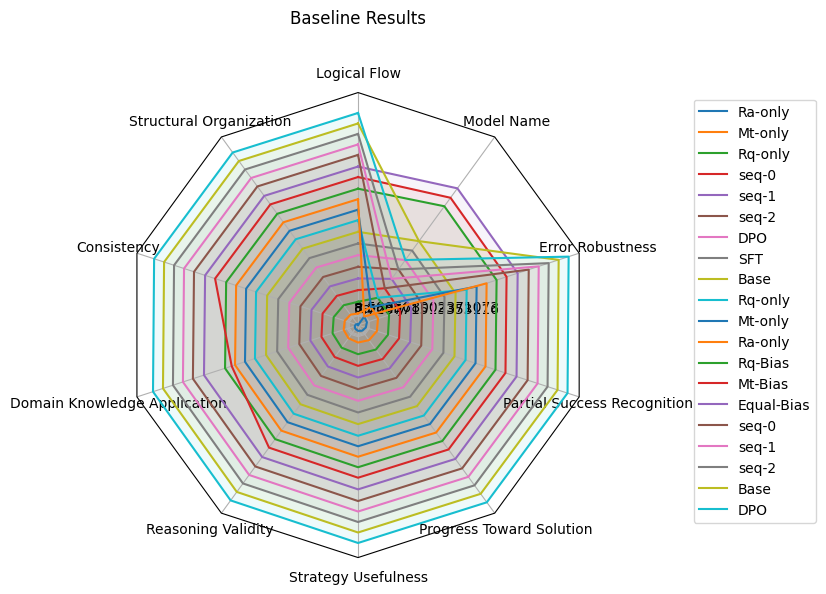

In [93]:

data = [final_df.columns.tolist(),
        ('Baseline Results', final_df.values.tolist())]

N = len(data[0])
theta = radar_factory(N, frame='polygon')

spoke_labels = data.pop(0)
title, case_data = data[0]

fig, ax = plt.subplots(figsize=(6, 16), subplot_kw=dict(projection='radar'))
fig.subplots_adjust(top=0.85, bottom=0.05)

ax.set_rgrids([8,9,10])
ax.set_title(title, ha='center', pad=50)

for i,d in enumerate(case_data):
    line = ax.plot(theta, d, label=ablatiobn_names[i])
    ax.fill(theta, d,  alpha=0.07)
ax.set_varlabels(spoke_labels)

ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1))
plt.show()

In [11]:
final_df.values.min() ,\
final_df.values.max()

(7.0887767220902616, 9.18219584569733)

In [12]:
qwen_models = all_df[all_df['model'] == 'qwen']

In [47]:
m1 = qwen_models['model_type'] == 'Base'
m2 = qwen_models['Final Answer Correctness'] == 10.0
m3 = qwen_models['model_type'] == 'Mt-only'
m4 = qwen_models['Final Answer Correctness'] != 10.0
correct_base = qwen_models[m1][m2]
incorrect_other = qwen_models[m3][m4]

common_keys = set(correct_base["question"]).intersection(incorrect_other["question"])
df1_common = correct_base[correct_base["question"].isin(common_keys)]
df2_common = incorrect_other[incorrect_other["question"].isin(common_keys)]

df_result = pd.concat([df1_common, df2_common], ignore_index=True).reset_index(drop=True)

C:\Users\kachr\AppData\Local\Temp\ipykernel_12780\1936715844.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  correct_base = qwen_models[m1][m2]
C:\Users\kachr\AppData\Local\Temp\ipykernel_12780\1936715844.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  incorrect_other = qwen_models[m3][m4]


In [48]:
incorrect_other

,bench,question,gold,pred_text,pred_num,correct,Logical Flow,Structural Organization,Consistency,Factual Correctness,...,Error Robustness,verbosity,final_comment,gold_norm,pred_raw,extract_method,pred_norm,partial_correct,model,model_type
1692,gsm,"Every day, Wendi feeds each of her chickens th...",20,Rq: Rephrase: If Wendi gives each chicken 3 cu...,25.0,False,9.5,9.5,10.0,7.0,...,4.0,long,The model's reasoning is clearly structured an...,None,None,None,None,NaN,qwen,Mt-only
1693,gsm,Janet’s ducks lay 16 eggs per day. She eats th...,18,Rq: Rephrase: Determine how much money Janet m...,2.0,False,8.0,8.5,8.5,7.0,...,7.0,long,The model follows a logical and structured app...,None,None,None,None,NaN,qwen,Mt-only
1694,gsm,Carla is downloading a 200 GB file. Normally s...,160,"To solve this problem, let's break it down ste...",120.0,False,9.0,9.5,9.0,7.0,...,7.0,long,"The reasoning is well-structured and clear, bu...",None,None,None,None,NaN,qwen,Mt-only
1696,gsm,John drives for 3 hours at a speed of 60 mph a...,45,Rq: Rephrase: Determine the distance John is f...,80.0,False,8.5,9.0,8.5,7.0,...,7.0,long,"The model demonstrates a clear, stepwise appro...",None,None,None,None,NaN,qwen,Mt-only
1703,gsm,Toula went to the bakery and bought various ty...,694,Rq: Rephrase: Calculate the total cost of 3 do...,704.0,False,9.0,9.0,10.0,10.0,...,8.0,long,The model's reasoning is well-structured and a...,None,None,None,None,NaN,qwen,Mt-only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3366,Minerva,Preamble: Suppose there are exactly two consum...,\alpha,To find the own-price elasticity of demand for...,NaN,False,9.5,9.5,9.5,8.5,...,8.0,long,The model's reasoning is well-structured and a...,\alpha,"[-, \, [, \, {, {, }, }, =, \, {, \, {, }, }, ...",last_line,"['-', '\\', '[', '\\', '{', '{', '}', '}', '='...",0.0,qwen,Mt-only
3367,Minerva,Compute the momentum of one $500 \mathrm{~nm}$...,1.325e-27,Rq: Rephrase: Calculate the momentum of a 500 ...,NaN,False,8.5,8.5,9.0,9.0,...,7.5,long,The solution follows a correct and well-struct...,1.32500000000000e-27,"[5, 0, 0, (, {, \, {, }, }, =, \, {, {, \, {, ...",last_line,"[5, 0, 0, '(', '{', '\\', '{', '}', '}', '=', ...",0.0,qwen,Mt-only
3369,Minerva,Preamble: Consider the 3-level $\mathbf{H}$ ma...,10.1,Rq: Rephrase: Using non-degenerate perturbatio...,NaN,False,2.0,2.0,1.0,1.0,...,0.0,long,The response does not attempt the required qua...,10.1000000000000,"[-, {, \, {, 1, 0, }, }, 3, -, \, {, }, 1, 2, ...",last_line,"['-', '{', '\\', '{', 1, 0, '}', '}', 3, '-', ...",0.0,qwen,Mt-only
3370,Minerva,"Preamble: This problem deals with the H\""uckel...",11.9,Rq: Rephrase: Calculate the ionization potenti...,NaN,False,6.0,6.5,6.0,4.0,...,3.0,long,The response outlines a general strategy but f...,11.9000000000000,"[\, {, \, {, }, }, =, -, 1, 1, 2, \, {, }, \, ...",last_line,"['\\', '{', '\\', '{', '}', '}', '=', '-', 1, ...",0.0,qwen,Mt-only


In [49]:
df1_common[['question', 'Final Answer Correctness', 'model_type']].sort_values(by="question").reset_index(drop=True)

,question,Final Answer Correctness,model_type
0,(Continue from the previous question.) Which o...,10.0,Base
1,"A circle in the xy-plane has its center at (4,...",10.0,Base
2,A classroom has a whiteboard which is shared b...,10.0,Base
3,"A cobra, which has 70 spots, has twice as many...",10.0,Base
4,A distance 112 furlongs is equivalent to how m...,10.0,Base
...,...,...,...
110,What is the total cost of 3 jars of peanut but...,10.0,Base
111,When $(2x^{3}-\frac{1}{x})^{6}$ is multiplied ...,10.0,Base
112,When the quadratic function f is graphed in th...,10.0,Base
113,When the roots of the polynomial $P(x)=(x-1)^{...,10.0,Base


In [50]:
df2_common[['question', 'Final Answer Correctness', 'model_type']].sort_values(by="question").reset_index(drop=True)

,question,Final Answer Correctness,model_type
0,(Continue from the previous question.) Which o...,0.0,Mt-only
1,"A circle in the xy-plane has its center at (4,...",0.0,Mt-only
2,A classroom has a whiteboard which is shared b...,0.0,Mt-only
3,"A cobra, which has 70 spots, has twice as many...",0.0,Mt-only
4,A distance 112 furlongs is equivalent to how m...,0.0,Mt-only
...,...,...,...
110,What is the total cost of 3 jars of peanut but...,0.0,Mt-only
111,When $(2x^{3}-\frac{1}{x})^{6}$ is multiplied ...,0.0,Mt-only
112,When the quadratic function f is graphed in th...,2.0,Mt-only
113,When the roots of the polynomial $P(x)=(x-1)^{...,3.0,Mt-only


In [55]:
for key, group in df_result.groupby("question"):
    print(f"\nGroup for key={key}:")
    
    # group behaves like a normal DataFrame
    group = group.reset_index()
    # print(qwen_models.loc[1, 'model_type'])
    # print(qwen_models.loc[1, 'question'])
    print("correct base")
    print(group.loc[0, 'pred_text'])
    print(group.loc[0, 'final_comment'])
    print("\n\n\n")
    print("incorrect Mt-only")
    print(group.loc[1, 'pred_text'])
    print(group.loc[1, 'final_comment'])
    break
# group.head()


Group for key=(Continue from the previous question.) Which of the following is a possible value for the median trunk diameter, in inches, of these trees: (A) 10 (B) 15 (C) 20 (D) 25:
correct base
? Given the data set: 8, 12, 15, 18, 22, 25, 30.
Rq: Rephrase: Determine which of the provided options could be the median trunk diameter of the trees based on the given data set: 8, 12, 15, 18, 22, 25, 30.
Mt: Step 1: Understand that the median is the middle number in an ordered list of numbers. Step 2: Confirm the data set is already ordered. Step 3: Identify the position of the median in a list of 7 numbers (it will be the 4th number). Step 4: Locate the 4th number in the data set to find the median. Step 5: Check if any of the given options match the identified median.
Ra: 18

Question: (Continue from the previous question.) If the median trunk diameter is 18 inches, what is the mode of the trunk diameters?
Rq: Rephrase: Given the data set: 8, 12, 15, 18, 22, 25, 30, and knowing the media

In [94]:
all_df['Final Answer Correctness'] = all_df['Final Answer Correctness']*10

In [109]:
all_df_grouped = all_df.groupby(["model", "model_type", "bench"]).agg({
    "Logical Flow": ["mean"],
    "Consistency": ["mean"],
    "Reasoning Validity": ["mean"],
    "Final Answer Correctness": ["mean"],
})
all_df_grouped

Logical Flow Consistency Reasoning Validity  \
                                 mean        mean               mean   
model model_type bench                                                 
llama Base       Minerva     7.837638    7.800738           6.926199   
                 aime24      4.816667    4.800000           3.716667   
                 gk          7.471279    7.415144           6.732376   
                 gsm         9.290000    9.205000           8.980000   
                 math500     7.695783    7.648594           6.959839   
...                               ...         ...                ...   
qwen  seq-2      Minerva     8.442804    8.553506           7.885609   
                 aime24      6.666667    6.750000           5.800000   
                 gk          8.981818    9.032468           8.592208   
                 gsm         9.822645    9.846693           9.683367   
                 math500     9.043000    9.121000           8.704000   

                         Final Answer Correctness  
                                             mean  
model model_type bench                             
llama Base       Minerva                42.583026  
                 aime24                  7.333333  
                 gk                     46.031332  
                 gsm                    81.800000  
                 math500                47.078313  
...                                           ...  
qwen  seq-2      Minerva                47.653137  
                 aime24                  3.333333  
                 gk                     61.116883  
                 gsm                    90.090180  
                 math500                66.510000  

[100 rows x 4 columns]

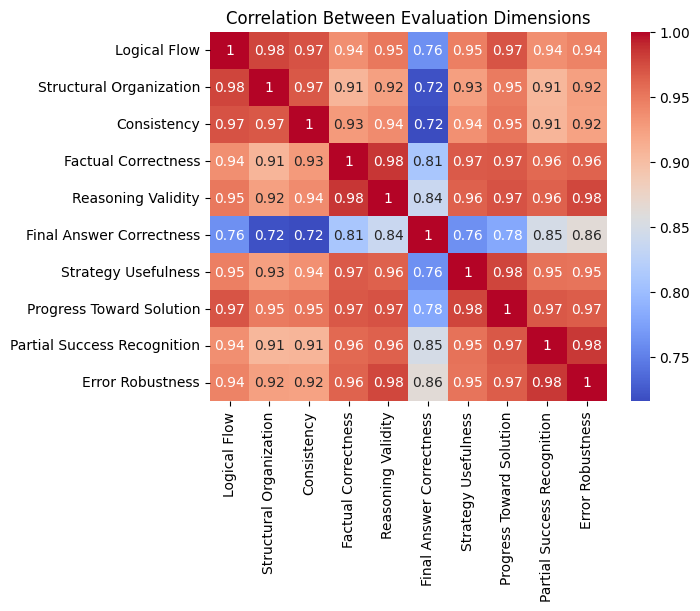

In [96]:
import seaborn as sns, matplotlib.pyplot as plt
num_cols = ["Logical Flow", 
            "Structural Organization", 
            "Consistency",
            "Factual Correctness", 
            "Reasoning Validity",
            "Final Answer Correctness", 
            "Strategy Usefulness",
            "Progress Toward Solution", 
            "Partial Success Recognition",
            "Error Robustness"]

corr = all_df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Evaluation Dimensions")
plt.show()


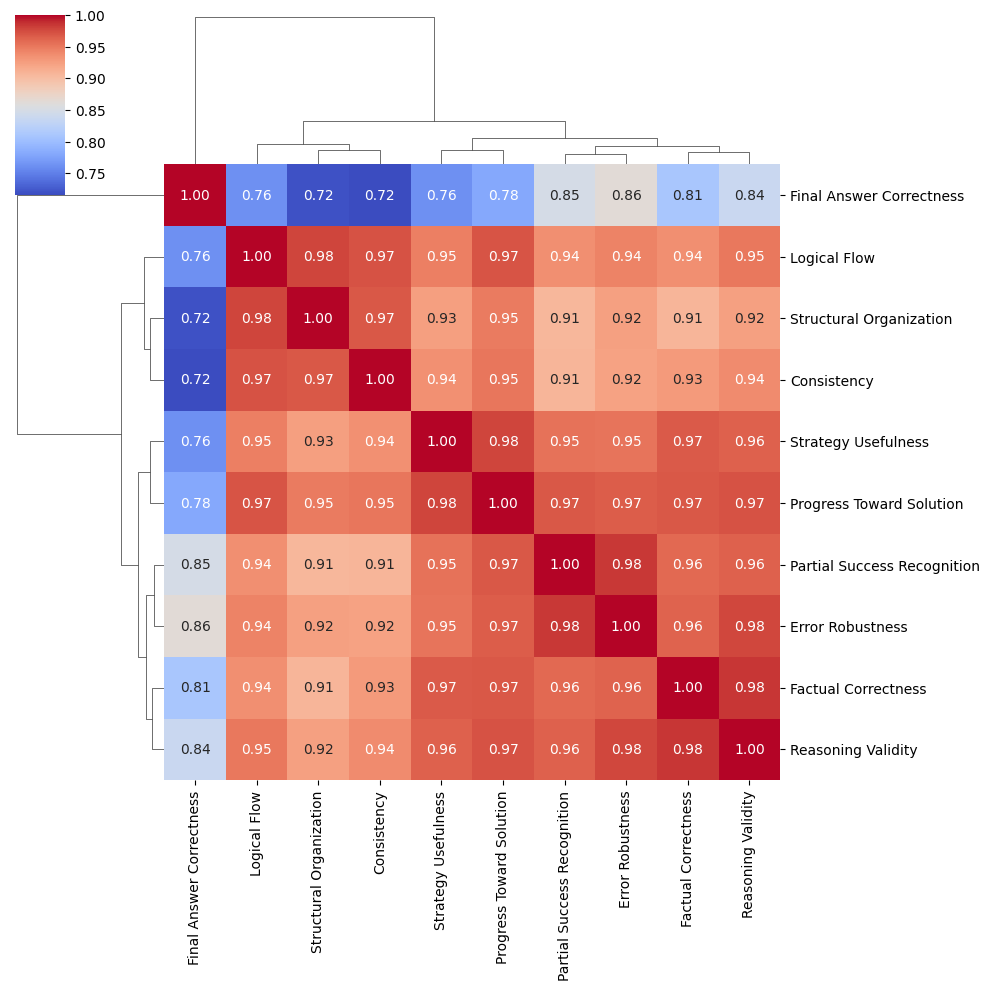

In [97]:
sns.clustermap(corr, annot=True, cmap="coolwarm", fmt=".2f")

In [98]:
from numpy.linalg import eigvals

eigvals_corr = eigvals(corr)
explained_var_ratio = eigvals_corr / eigvals_corr.sum()

In [99]:
explained_var_ratio

array([9.28620937e-01, 4.04615545e-02, 1.34630057e-02, 5.59830479e-03,
       3.46329281e-03, 2.64350706e-03, 2.21879247e-03, 8.14255369e-04,
       1.23943906e-03, 1.47691086e-03])

That means nearly all rubric dimensions (Logical Flow, Consistency, Reasoning Validity, etc.) are driven by a single underlying latent variable — what we can call “General Reasoning Quality” or “Unified Reasoning Coherence.”

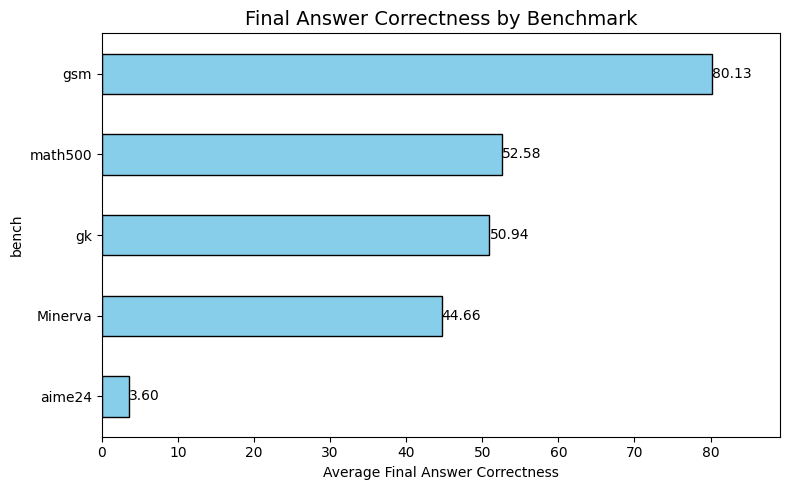

In [104]:
bench_stats = all_df.groupby("bench")["Final Answer Correctness"].mean().sort_values()

plt.figure(figsize=(8,5))
bars = bench_stats.plot(kind="barh", color="skyblue", edgecolor="black")

plt.title("Final Answer Correctness by Benchmark", fontsize=14)
plt.xlabel("Average Final Answer Correctness")

# Add value labels on bars
for i, (value, name) in enumerate(zip(bench_stats, bench_stats.index)):
    plt.text(value, i, f"{value:.2f}", va='center', fontsize=10)

plt.xlim(0, bench_stats.max() + 9)  # small margin
plt.tight_layout()
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Ra-only'),
  Text(1, 0, 'Mt-only'),
  Text(2, 0, 'Rq-only'),
  Text(3, 0, 'seq-0'),
  Text(4, 0, 'seq-1'),
  Text(5, 0, 'seq-2'),
  Text(6, 0, 'DPO'),
  Text(7, 0, 'SFT'),
  Text(8, 0, 'Base')])

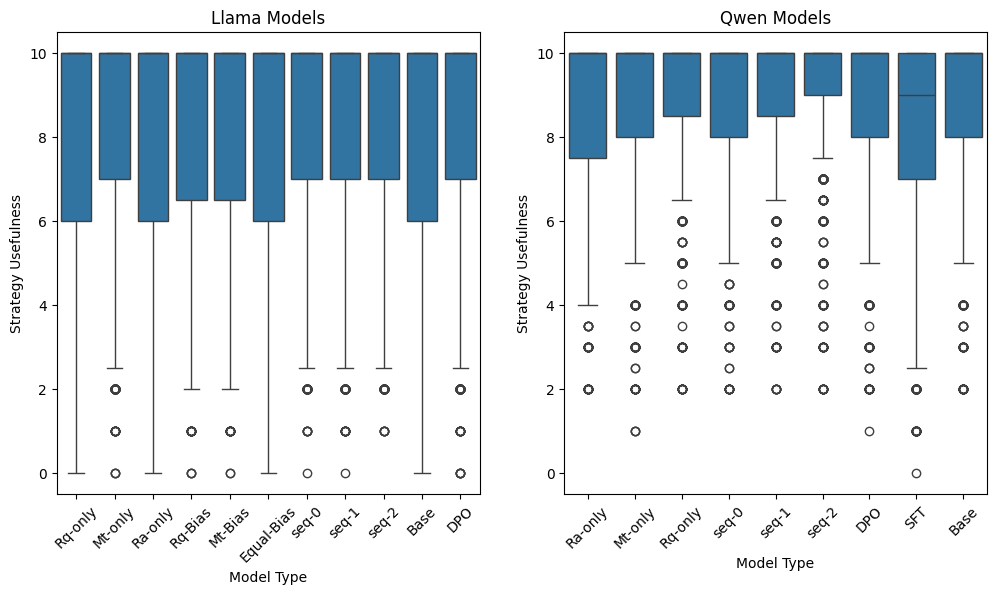

In [117]:
llama = all_df[all_df['model'].str.contains('llama')]
qwen = all_df[all_df['model'].str.contains('qwen')]

plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
sns.boxplot(data=llama, x="model_type", y="Strategy Usefulness")
plt.title("Llama Models")
plt.xlabel("Model Type")
plt.ylabel("Strategy Usefulness")
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.boxplot(data=qwen, x="model_type", y="Strategy Usefulness")
plt.title("Qwen Models")
plt.xlabel("Model Type")
plt.ylabel("Strategy Usefulness")
plt.xticks(rotation=45)

In [137]:
all_df['final_comment'].values[:30]

array(['The model provides a clear, stepwise, and fully correct solution with all reasoning and calculations accurate and well-structured.',
       "The model's reasoning is clear, stepwise, and factually correct, and the final answer of 460.00 matches the gold answer; the 'correct' flag should be true.",
       'The model provides a clear, correct, and well-structured solution with all reasoning steps logically leading to the correct answer.',
       "The model's reasoning is fully correct and the final answer matches the gold answer; the 'correct' flag should be overridden to true.",
       "The model's reasoning is fully correct, well-structured, and arrives at the correct answer of $70,000; the pred_num extraction was faulty and should be overridden to 70000.",
       'The model provides a clear, stepwise, and correct solution that matches the gold answer.',
       'The reasoning is clear and correct in structure, but the model misapplies the price per egg (should be $2 per egg, no

In [133]:
import re
import pandas as pd

# Define pattern-based categories
label_patterns = {
    "Correct Reasoning": [
        r"\bclear reasoning\b", r"\bcorrect reasoning\b", r"\blogical\b",
        r"\bwell-structured\b", r"\baccurate\b", r"\bfully correct\b"
    ],
    "Calculation Error": [
        r"\bcalculation error\b", r"\bwrong calculation\b", r"\barithmetic mistake\b",
        r"\bcomputed incorrectly\b", r"\bmath error\b"
    ],
    "Misinterpretation": [
        r"\bmisinterpret\b", r"\bmisunderstood\b", r"\bwrong assumption\b",
        r"\bincorrectly interpreted\b", r"\bfaulty assumption\b"
    ],
    "Extraction Error": [
        r"\bextraction\b", r"\bpred_num extraction\b", r"\bparser\b", r"\bformat\b"
    ],
    "Incomplete Reasoning": [
        r"\bpartial\b", r"\bincomplete\b", r"\bmissing step\b", r"\bskipped\b"
    ],
    "Hallucination": [
        r"\bhallucinate\b", r"\bmade up\b", r"\bincorrectly added\b"
    ]
}
def assign_labels(comment, patterns):
    labels = []
    text = str(comment).lower()
    for label, regex_list in patterns.items():
        for regex in regex_list:
            if re.search(regex, text):
                labels.append(label)
                break
    return labels if labels else ["Uncategorized"]

all_df["comment_labels"] = all_df["final_comment"].apply(lambda x: assign_labels(x, label_patterns))


C:\Users\kachr\AppData\Local\Temp\ipykernel_12780\3996316374.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.values, y=label_counts.index, palette="crest")


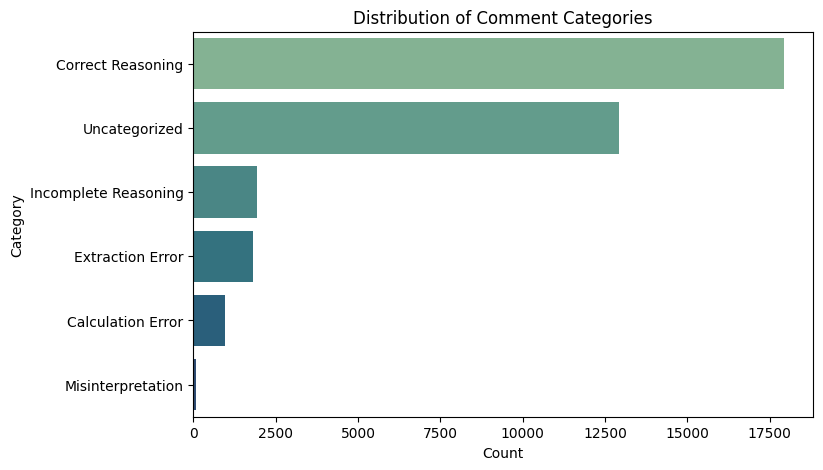

In [134]:
from itertools import chain
import seaborn as sns
import matplotlib.pyplot as plt

# Flatten multi-labels
label_counts = pd.Series(list(chain.from_iterable(all_df["comment_labels"]))).value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=label_counts.values, y=label_counts.index, palette="crest")
plt.title("Distribution of Comment Categories")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()


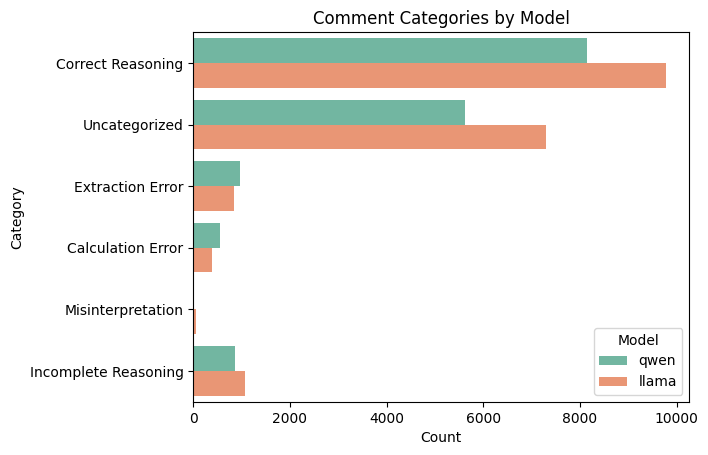

In [135]:
from collections import Counter

def count_labels(label_list):
    return Counter(label_list)

label_expanded = all_df.explode("comment_labels")
sns.countplot(y="comment_labels", hue="model", data=label_expanded, palette="Set2")
plt.title("Comment Categories by Model")
plt.xlabel("Count")
plt.ylabel("Category")
plt.legend(title="Model")
plt.show()


In [136]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(all_df["final_comment"].fillna(""), show_progress_bar=True)

kmeans = KMeans(n_clusters=6, random_state=42).fit(embeddings)
all_df["comment_cluster"] = kmeans.labels_


c:\Users\kachr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:13: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange


c:\Users\kachr\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\kachr\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\kachr\AppData\Local\Programs\Python\Python311\Lib\site-packages\tr

In [140]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

comments = all_df["final_comment"].fillna("").astype(str)
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X = vectorizer.fit_transform(comments)

terms = np.array(vectorizer.get_feature_names_out())
cluster_labels = all_df["comment_cluster"].values

n_top_words = 100
top_terms_per_cluster = {}

for cluster_num in sorted(set(cluster_labels)):
    cluster_indices = np.where(cluster_labels == cluster_num)[0]
    cluster_tfidf = X[cluster_indices].mean(axis=0)
    top_indices = np.argsort(cluster_tfidf.A1)[::-1][:n_top_words]
    top_terms_per_cluster[cluster_num] = terms[top_indices]


In [141]:
for cluster_num, words in top_terms_per_cluster.items():
    
    print(f"\n🧠 Cluster {cluster_num} — Top Terms:")
    print(", ".join(words))



🧠 Cluster 0 — Top Terms:
correct, flag, true, answer, overridden, fully, model, reasoning, structured, final, clear, gold, arrives, matches, stepwise, solution, provides, clearly, logically, marked, leads, correctness, sound, standard, despite, initial, step, exact, thorough, accurate, reaches, incorrect, detailed, matching, leading, ultimately, correctly, steps, marking, produces, factually, extraction, right, exactly, 10, frac, derivation, directly, false, identifies, mathematically, 50, excessive, explanation, arriving, ordered, calculations, applies, 11, repetition, repeated, output, 25, option, 15, identifying, logical, 16, extracted, formatting, 36, issue, incorrectly, incorrectness, 12, 21, 20, explicitly, 00, error, 120, 60, 13, 18, 45, value, complete, verbosity, 28, verbose, justified, issues, explained, set, 90, valid, reached, stated, 17, derived

🧠 Cluster 1 — Top Terms:
provides, solution, correct, step, clear, accurate, fully, stepwise, calculations, model, structured, 

In [150]:
cluster_names = {
    0: "Correct & Structured",
    1: "Verbose but Correct",
    2: "Flawed Reasoning/\n Logic Error",
    3: "Extraction or\n Formatting Issue",
    4: "Calculation /\n Conceptual Error",
    5: "Exemplary Solution"
}
all_df["cluster_name"] = all_df["comment_cluster"].map(cluster_names)

C:\Users\kachr\AppData\Local\Temp\ipykernel_12780\1752574996.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=all_df["cluster_name"], palette="crest")


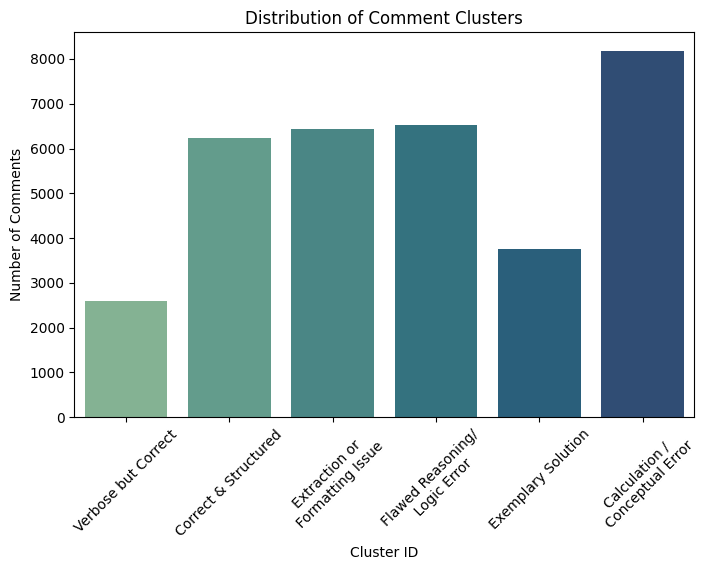

In [151]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x=all_df["cluster_name"], palette="crest")
plt.title("Distribution of Comment Clusters")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.show()


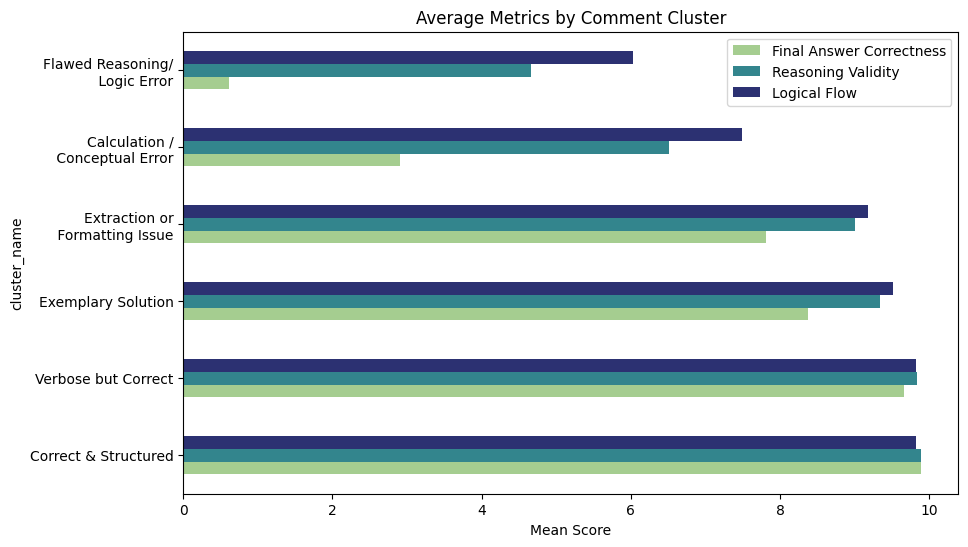

In [153]:
metrics = ["Final Answer Correctness", "Reasoning Validity", "Logical Flow"]

cluster_perf = all_df.groupby("cluster_name")[metrics].mean().sort_values("Final Answer Correctness", ascending=False)
cluster_perf['Final Answer Correctness'] = cluster_perf['Final Answer Correctness'] / 10.0
cluster_perf.plot(kind="barh", figsize=(10,6), colormap="crest")
plt.title("Average Metrics by Comment Cluster")
plt.xlabel("Mean Score")
plt.show()


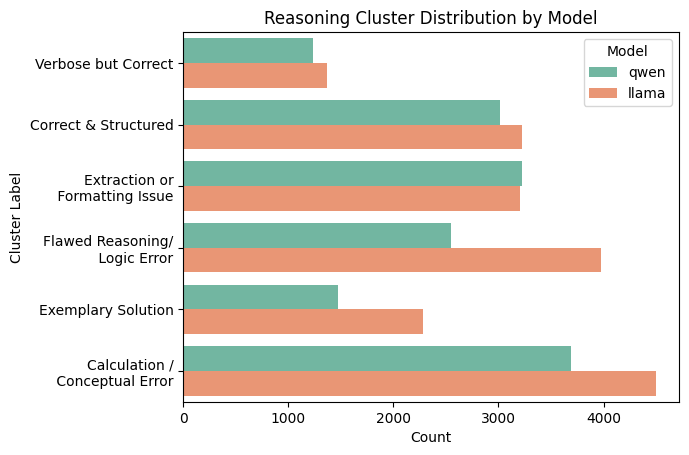

In [154]:
sns.countplot(y="cluster_name", hue="model", data=all_df, palette="Set2")
plt.title("Reasoning Cluster Distribution by Model")
plt.xlabel("Count")
plt.ylabel("Cluster Label")
plt.legend(title="Model")
plt.show()


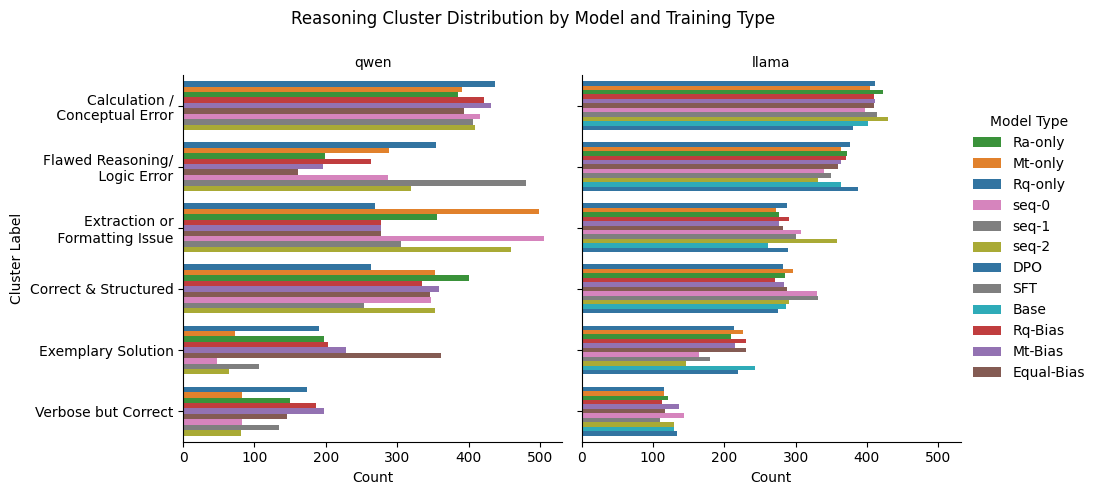

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(all_df, col="model", sharey=True, height=5, aspect=1)
g.map_dataframe(sns.countplot, y="cluster_name", hue="model_type", order=all_df["cluster_name"].value_counts().index, palette="tab20c")
g.add_legend(title="Model Type")
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Count", "Cluster Label")
plt.subplots_adjust(top=0.85)
g.fig.suptitle("Reasoning Cluster Distribution by Model and Training Type")
plt.show()
